In [2]:
!pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)

In [4]:
print(heart_disease)

{'data': {'ids': None, 'features':      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   1       145   233    1        2      150      0      2.3   
1     67    1   4       160   286    0        2      108      1      1.5   
2     67    1   4       120   229    0        2      129      1      2.6   
3     37    1   3       130   250    0        0      187      0      3.5   
4     41    0   2       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   1       110   264    0        0      132      0      1.2   
299   68    1   4       144   193    1        0      141      0      3.4   
300   57    1   4       130   131    0        0      115      1      1.2   
301   57    0   2       130   236    0        2      174      0      0.0   
302   38    1   3       138   175    0        0      173      0      0.0   

     slope   ca  thal  
0        3  0.0   6.0  
1   

In [5]:
heart_disease.data.features.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

In [6]:
heart_disease.data.features[["ca", "thal"]].value_counts(dropna=False)

ca   thal
0.0  3.0     115
     7.0      51
1.0  7.0      32
     3.0      29
2.0  7.0      20
     3.0      14
3.0  7.0      12
0.0  6.0       8
3.0  3.0       6
1.0  6.0       4
2.0  6.0       4
0.0  NaN       2
3.0  6.0       2
NaN  3.0       2
     7.0       2
Name: count, dtype: int64

In [7]:
heart_disease.data.features["ca"].median()

0.0

In [8]:
heart_disease.data.features["thal"].median()

3.0

In [9]:
heart_disease.data.features["ca"].mode()

0    0.0
Name: ca, dtype: float64

In [10]:
heart_disease.data.features["thal"].mode()

0    3.0
Name: thal, dtype: float64

In [11]:
X = heart_disease.data.features.copy()

X["ca"] = X["ca"].fillna(X["ca"].mode()[0])
X["thal"] = X["thal"].fillna(X["thal"].mode()[0])

In [12]:
X.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

In [13]:
y = heart_disease.data.targets

In [14]:
y.value_counts()

num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64

In [15]:
y = (y["num"] > 0).astype(int)

In [16]:
y.value_counts()

num
0    164
1    139
Name: count, dtype: int64

In [17]:
X.shape

(303, 13)

In [18]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    float64
 12  thal      303 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB


In [20]:
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.663366,4.722772
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.934375,1.938383
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [21]:
y.value_counts()

num
0    164
1    139
Name: count, dtype: int64

In [23]:
import matplotlib.pyplot as plt

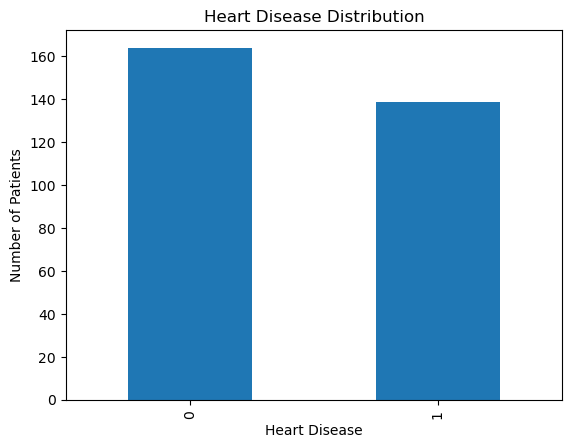

In [24]:
y.value_counts().plot(kind="bar")

plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Distribution")
plt.show()

In [25]:
df = X.copy()
df["target"] = y

In [26]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,1
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


In [27]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [28]:
df["target"].value_counts()

target
0    164
1    139
Name: count, dtype: int64

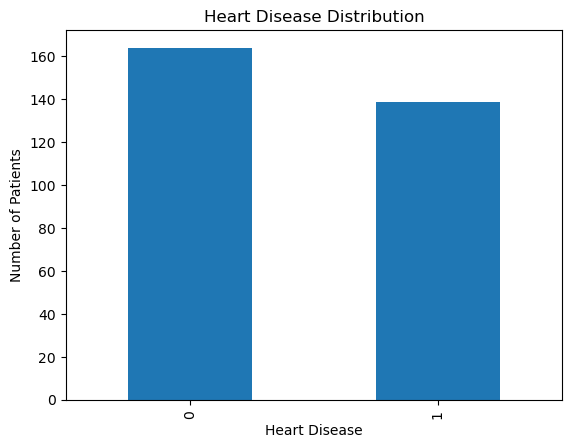

In [29]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")

plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")
plt.title("Heart Disease Distribution")
plt.show()

In [30]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [31]:
df.groupby("target")["age"].mean()

target
0    52.585366
1    56.625899
Name: age, dtype: float64

In [32]:
df.groupby("target")

In [35]:
df.groupby("target")["age"].mean()

target
0    52.585366
1    56.625899
Name: age, dtype: float64

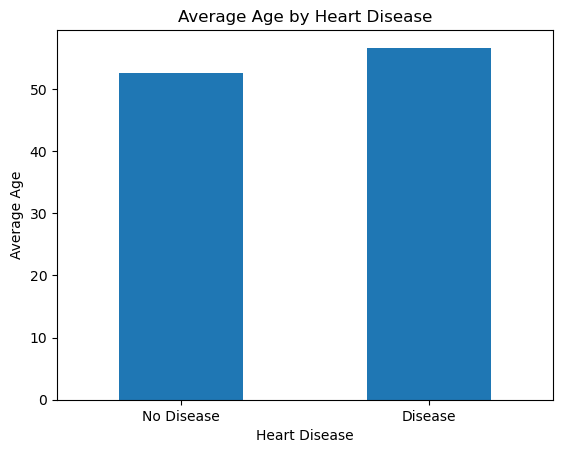

In [36]:
df.groupby("target")["age"].mean().plot(kind="bar")

plt.xlabel("Heart Disease")
plt.ylabel("Average Age")
plt.title("Average Age by Heart Disease")
plt.xticks([0, 1], ["No Disease", "Disease"], rotation=0)

plt.show()

In [37]:
df.groupby("target")["thalach"].mean()

target
0    158.378049
1    139.258993
Name: thalach, dtype: float64

In [38]:
df.groupby("target")["chol"].mean()

target
0    242.640244
1    251.474820
Name: chol, dtype: float64

In [39]:
df.groupby("target")["trestbps"].mean()


target
0    129.250000
1    134.568345
Name: trestbps, dtype: float64

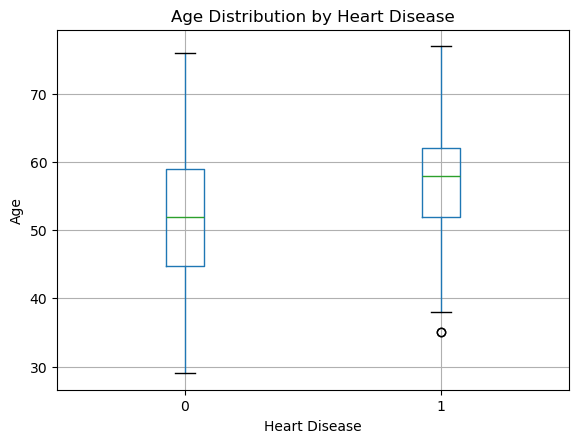

In [40]:
df.boxplot(column="age", by="target")

plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.title("Age Distribution by Heart Disease")
plt.suptitle("")
plt.show()

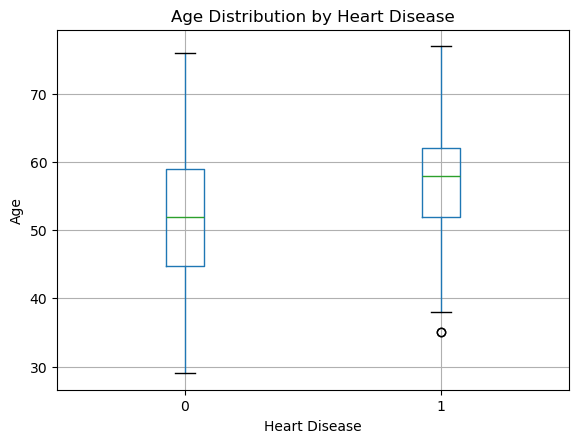

In [41]:
df.boxplot(column="age", by="target")

plt.xlabel("Heart Disease")
plt.ylabel("Age")
plt.title("Age Distribution by Heart Disease")
plt.suptitle("")
plt.show()

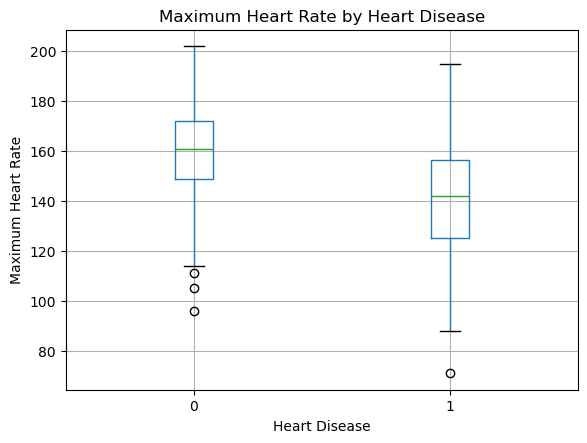

In [42]:
df.boxplot(column="thalach", by="target")

plt.xlabel("Heart Disease")
plt.ylabel("Maximum Heart Rate")
plt.title("Maximum Heart Rate by Heart Disease")
plt.suptitle("")
plt.show()

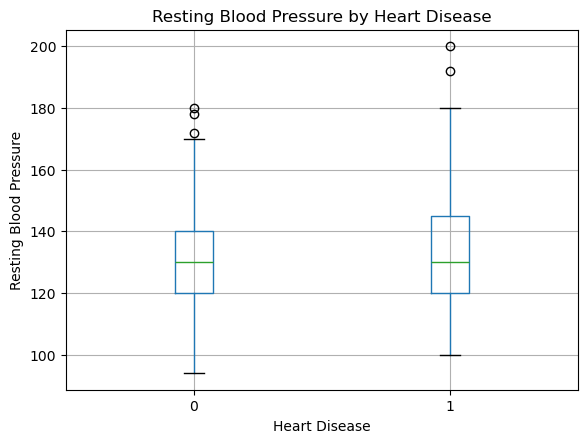

In [43]:
df.boxplot(column="trestbps", by="target")

plt.xlabel("Heart Disease")
plt.ylabel("Resting Blood Pressure")
plt.title("Resting Blood Pressure by Heart Disease")
plt.suptitle("")
plt.show()

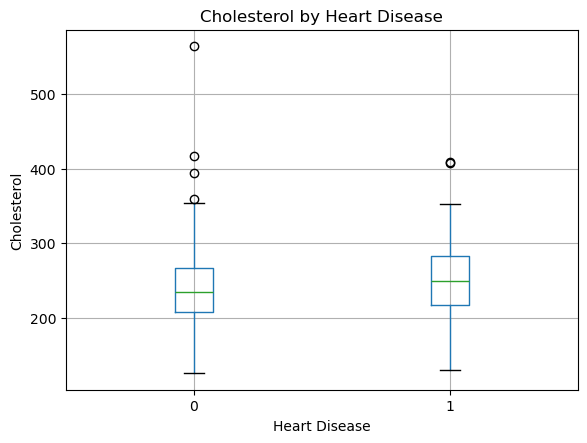

In [44]:
df.boxplot(column="chol", by="target")

plt.xlabel("Heart Disease")
plt.ylabel("Cholesterol")
plt.title("Cholesterol by Heart Disease")
plt.suptitle("")
plt.show()

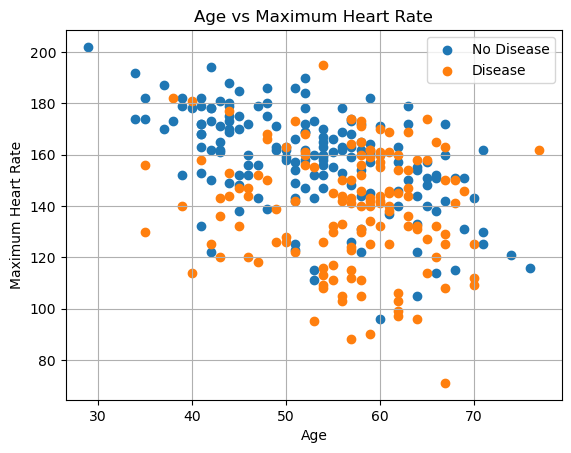

In [45]:
plt.scatter(
    df[df["target"] == 0]["age"],
    df[df["target"] == 0]["thalach"],
    label="No Disease"
)

plt.scatter(
    df[df["target"] == 1]["age"],
    df[df["target"] == 1]["thalach"],
    label="Disease"
)

plt.xlabel("Age")
plt.ylabel("Maximum Heart Rate")
plt.title("Age vs Maximum Heart Rate")
plt.legend()
plt.grid(True)

plt.show()

In [46]:
correlation = df.corr()

correlation

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.365323,0.128303,0.223120
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.086048,0.380581,0.276816
cp,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.233117,0.262089,0.414446
trestbps,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.097528,0.134424,0.150825
chol,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.123726,0.018351,0.085164
fbs,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.140764,0.064625,0.025264
restecg,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.131749,0.024325,0.169202
thalach,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.265699,-0.274142,-0.417167
exang,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145788,0.325240,0.431894
oldpeak,0.203805,0.102173,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.301067,0.342405,0.424510


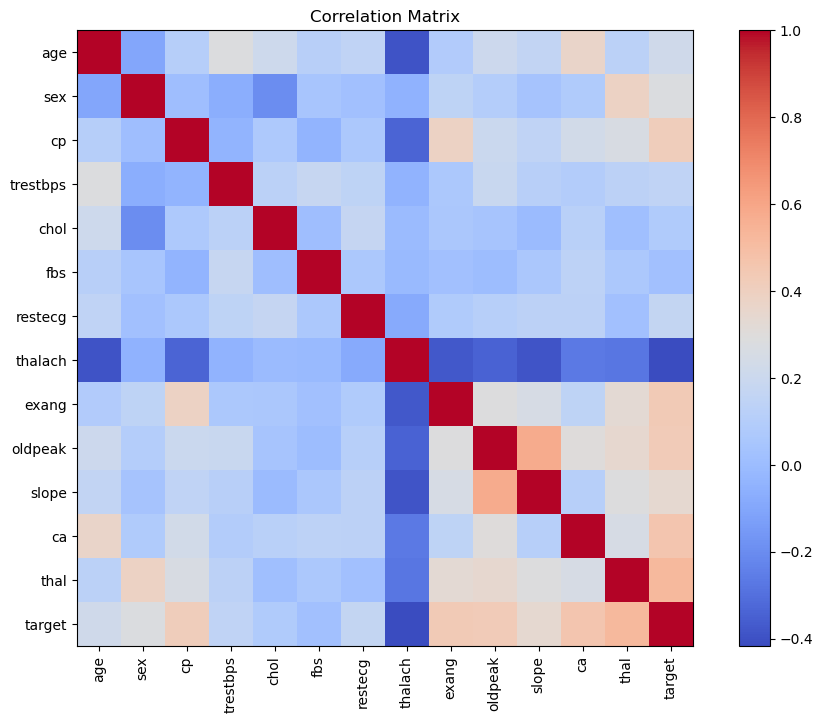

In [47]:
plt.figure(figsize=(12, 8))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Matrix")

plt.show()

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [49]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (242, 13)
X_test: (61, 13)
y_train: (242,)
y_test: (61,)


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
print(X_train_scaled[:5])

[[-0.72948484  0.68313005  0.8701687  -0.39569185  0.4581394  -0.41119597
   1.0229958   0.70837124 -0.69617712 -0.44544493  0.67505958 -0.68971531
   1.17997269]
 [ 0.05016647  0.68313005 -1.18427838 -0.05451337  0.23059762 -0.41119597
  -0.98157896  0.22249537 -0.69617712 -0.89162735 -0.9585846  -0.68971531
  -0.87806977]
 [-0.06121229 -1.46385011 -1.18427838  0.0592128   0.72360482  2.43193045
   1.0229958   0.3991775   1.43641607 -0.89162735 -0.9585846   0.44573438
  -0.87806977]
 [-0.06121229  0.68313005 -1.18427838 -1.30550115  1.12180294 -0.41119597
  -0.98157896  0.26666591 -0.69617712 -0.89162735 -0.9585846  -0.68971531
   1.17997269]
 [ 0.27292398 -1.46385011  0.8701687   0.51411744 -0.16760051 -0.41119597
  -0.98157896 -1.19096169  1.43641607 -0.71315438  0.67505958 -0.68971531
   1.17997269]]


In [52]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [54]:
y_pred = model.predict(X_test_scaled)

In [55]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8688524590163934


In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [57]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[27  6]
 [ 2 26]]


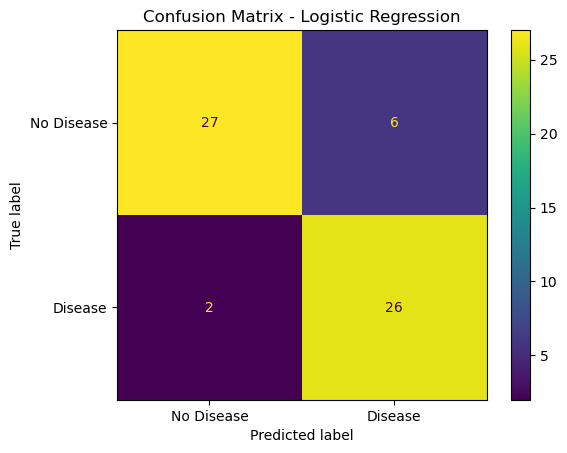

In [58]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [59]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[27  6]
 [ 2 26]]


In [61]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [62]:
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.8852459016393442


In [63]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_k = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy)

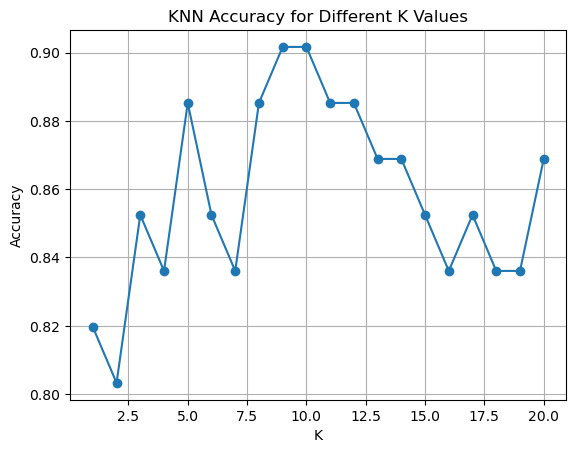

In [65]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred_k = knn.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy)

plt.plot(k_values, accuracies, marker="o")

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different K Values")
plt.grid(True)

plt.show()

In [67]:
best_k = k_values[list(accuracies).index(max(accuracies))]

print("Best K:", best_k)
print("Best Accuracy:", max(accuracies))

Best K: 9
Best Accuracy: 0.9016393442622951


In [68]:
knn_best = KNeighborsClassifier(n_neighbors=9)

knn_best.fit(X_train_scaled, y_train)

y_pred_knn = knn_best.predict(X_test_scaled)

In [69]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9016393442622951


In [70]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

print(cm_knn)

[[27  6]
 [ 0 28]]


In [71]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       1.00      0.82      0.90        33
           1       0.82      1.00      0.90        28

    accuracy                           0.90        61
   macro avg       0.91      0.91      0.90        61
weighted avg       0.92      0.90      0.90        61



In [72]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", random_state=42)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

In [73]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8524590163934426


In [74]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

svm_model = SVC(kernel="rbf", random_state=42)

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

SVM Accuracy: 0.8524590163934426

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61


Confusion Matrix:
[[27  6]
 [ 3 25]]


In [75]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

In [76]:
tree_accuracy = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:", tree_accuracy)

Decision Tree Accuracy: 0.7377049180327869


In [77]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.81      0.67      0.73        33
           1       0.68      0.82      0.74        28

    accuracy                           0.74        61
   macro avg       0.75      0.74      0.74        61
weighted avg       0.75      0.74      0.74        61



In [78]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Confusion Matrix:
[[22 11]
 [ 5 23]]


In [79]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [80]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8852459016393442


In [81]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



In [82]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Confusion Matrix:
[[28  5]
 [ 2 26]]


In [83]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross-Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Cross-Validation Scores: [0.91836735 0.7755102  0.83333333 0.83333333 0.77083333]
Mean Accuracy: 0.8262755102040817


In [84]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

k_values = range(1, 21)
cv_accuracies = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    cv_accuracies.append(scores.mean())

print("CV Accuracies:", cv_accuracies)

CV Accuracies: [0.7644557823129252, 0.7892857142857144, 0.8388605442176871, 0.8429421768707483, 0.8430272108843537, 0.8264455782312925, 0.8222789115646257, 0.8429421768707483, 0.8264455782312925, 0.8388605442176871, 0.8429421768707483, 0.8387755102040817, 0.8386904761904763, 0.8263605442176871, 0.8305272108843538, 0.8221938775510205, 0.8221938775510205, 0.8096938775510205, 0.8221088435374149, 0.8263605442176871]


In [85]:
best_k = k_values[list(cv_accuracies).index(max(cv_accuracies))]

print("Best K:", best_k)
print("Best CV Accuracy:", max(cv_accuracies))

Best K: 5
Best CV Accuracy: 0.8430272108843537


In [86]:
knn_cv = KNeighborsClassifier(n_neighbors=5)

knn_cv.fit(X_train_scaled, y_train)

y_pred_knn_cv = knn_cv.predict(X_test_scaled)

knn_cv_accuracy = accuracy_score(y_test, y_pred_knn_cv)

print("KNN Accuracy:", knn_cv_accuracy)

KNN Accuracy: 0.8852459016393442


In [90]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

In [91]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", scores)
print("Mean CV Accuracy:", scores.mean())

CV Scores: [0.89795918 0.7755102  0.85416667 0.77083333 0.85416667]
Mean CV Accuracy: 0.8305272108843538


In [92]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": model,
    "KNN": knn_pipeline,
    "SVM": svm_model,
    "Decision Tree": tree_model,
    "Random Forest": rf_model
}

for name, m in models.items():
    scores = cross_val_score(
        m,
        X_train_scaled if name in ["Logistic Regression", "SVM"] else X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    print(name, ":", scores.mean())

Logistic Regression : 0.8262755102040817
KNN : 0.8305272108843538
SVM : 0.8261904761904763
Decision Tree : 0.7435374149659864
Random Forest : 0.8055272108843538


In [93]:
knn_final = KNeighborsClassifier(n_neighbors=5)
knn_final.fit(X_train_scaled, y_train)

y_pred_final = knn_final.predict(X_test_scaled)

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))

Final Accuracy: 0.8852459016393442
